# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Answer: there are 17 marketing campaigns represented in this data

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [4]:
# check if there are any missing values
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [5]:
# check the number of unkown values in housing, loan, and default
print(df['housing'].value_counts())
print(df['loan'].value_counts())
print(df['default'].value_counts())

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


In [6]:
# check the relative frequency of each value in these columns
print(df['day_of_week'].value_counts())
print(df['marital'].value_counts())
print(df['job'].value_counts())
print(df['pdays'].value_counts())

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64


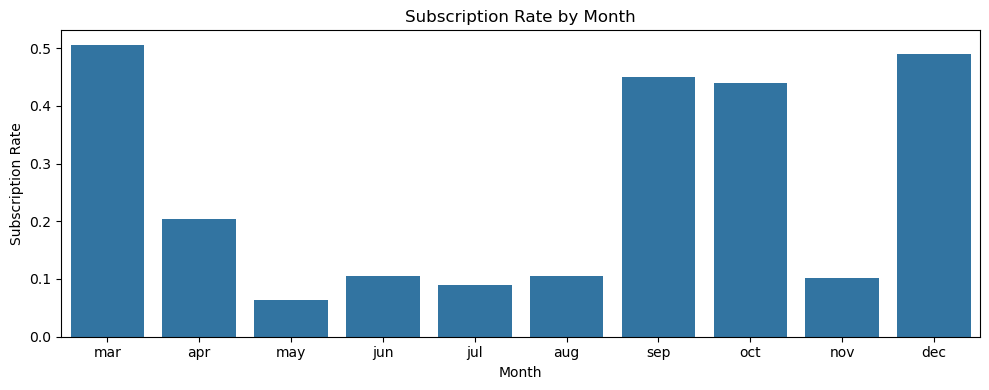

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# subscription rate by month
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug',
               'sep', 'oct', 'nov', 'dec']

month_rates = df.groupby('month')['y'].apply(
    lambda x: (x == 'yes').mean()
).reindex(month_order)

plt.figure(figsize=(10, 4))
sns.barplot(x=month_rates.index, y=month_rates.values)
plt.title('Subscription Rate by Month')
plt.xlabel('Month')
plt.ylabel('Subscription Rate')
plt.tight_layout()
plt.show()

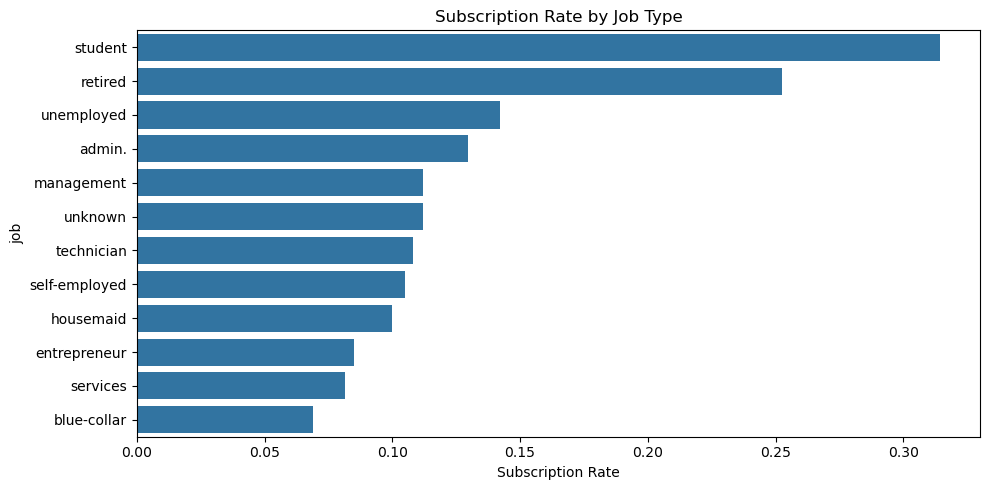

In [10]:
# subscription rate by job
job_rates = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean()
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=job_rates.values, y=job_rates.index)
plt.title('Subscription Rate by Job Type')
plt.xlabel('Subscription Rate')
plt.tight_layout()
plt.show()

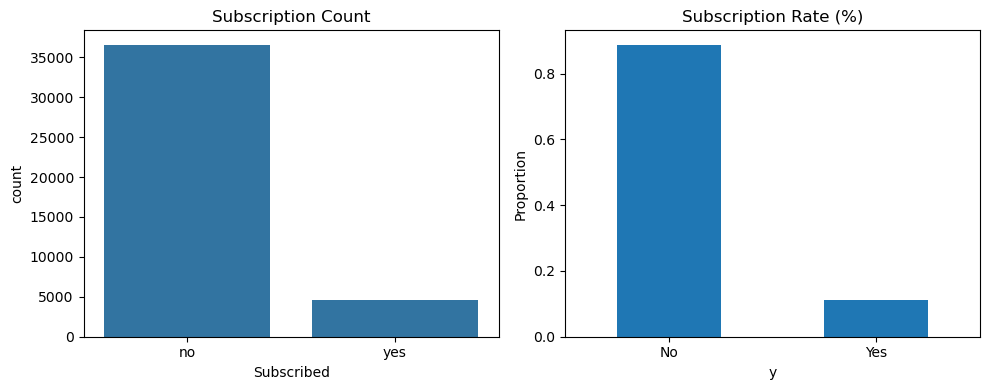

In [11]:
# plot the outcome column to see how many people said yes/no in the dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# count
sns.countplot(x='y', data=df, ax=axes[0])
axes[0].set_title('Subscription Count')
axes[0].set_xlabel('Subscribed')

# percentage
df['y'].value_counts(normalize=True).plot(kind='bar', ax=axes[1])
axes[1].set_title('Subscription Rate (%)')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

*   There are no null values in the table, but there are "unknown" values in some of the questions. We can either drop those rows, or fill them with another value if there's a reasonable one.

*   For housing and loan, unknown is a small percentage of the dataset, so we can update unknown to no, and use 0/1 for no/yes. For default, only 3 are yes and a large number are unknown, so we should just drop the column.

*   We want to drop the duration column as well, since it's not information we can know before the phone call, so is not useful for prediction (as noted in the docs)

*   In order to use the catgorical features, we'll need to encode them. For contact, there are only two columns so we can make it 0/1 for 'cellular'/'telephone'.

*   For education, there's an inherent order since it focused on the amount of education, so we can use ordinal encoding.

*   We can use one-hot encoding for the features with relatively few categories, like: marital (there are only a few unknown, so we can drop those rows and encode the remaining 3 values), poutcome (3 values), and day_of_week (5 values).

*   Job has 11 categories (we can drop rows with unknown since it's a small percentage), and month has 10 (there are no Jan or Feb dates). This is a larger number to one-hot encode, but we can try and see if performance is an issue.

*   Given that the pdays columns has ~39k of the 41k rows at 999, which indicates that they hadn't been reached out to before, we can change that column to has_been_contacted and make it false/true (0/1 encoded)

The actual encoding will be done in Problem 5

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The Business Objective is to determine what factors about a person make them more likely to accept the offered deposit terms, and to use that information to direct marketing resources towards the people more likely to accept.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

First, split the data into the input features (X) and the output (y). Then use train_test_split to split it into training and test data.

In [12]:
# Drop the default column (almost all no or unknown), and the duration column (can't be used for future prediction)
df_encoded = df.drop(columns=['duration', 'default'])
df_encoded.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [13]:
# Drop rows where unknown appears in columns we're one-hot encoding
df_encoded = df_encoded[df_encoded['marital'] != 'unknown'].copy()
df_encoded = df_encoded[df_encoded['job'] != 'unknown'].copy()
df_encoded.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [14]:
# housing and loan: unknown → no, then binary encode
for col in ['housing', 'loan']:
    df_encoded[col] = df_encoded[col].replace('unknown', 'no')
    df_encoded[col] = df_encoded[col].map({'no': 0, 'yes': 1})
df_encoded.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,1,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,0,0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,0,1,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [15]:
# contact: binary encode
df_encoded['contact'] = df_encoded['contact'].map({'cellular': 1, 'telephone': 0})
df_encoded.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,1,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,0,1,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [16]:
# for eduction, drop unknown then ordinal encode the rest
edu_order = {'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3, 'high.school': 4, 'professional.course': 5, 'university.degree': 6}
df_encoded = df_encoded[df_encoded['education'] != 'unknown'].copy()
df_encoded['education'] = df_encoded['education'].map(edu_order)
df_encoded.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,1,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,4,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,4,1,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,2,0,0,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,4,0,1,0,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [17]:
# one-hot encode: marital, poutcome, day_of_week, job, month
ohe_cols = ['marital', 'poutcome', 'day_of_week', 'job', 'month']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)
df_encoded.head()

,age,education,housing,loan,contact,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,job_unemployed,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,56,1,0,0,0,1,999,0,1.1,93.994,...,False,False,False,False,False,False,True,False,False,False
1,57,4,0,0,0,1,999,0,1.1,93.994,...,False,False,False,False,False,False,True,False,False,False
2,37,4,1,0,0,1,999,0,1.1,93.994,...,False,False,False,False,False,False,True,False,False,False
3,40,2,0,0,0,1,999,0,1.1,93.994,...,False,False,False,False,False,False,True,False,False,False
4,56,4,0,1,0,1,999,0,1.1,93.994,...,False,False,False,False,False,False,True,False,False,False


In [18]:
df_encoded['has_been_contacted'] = df_encoded['pdays'].apply(lambda x: x != 999)
df_encoded = df_encoded.drop(columns=['pdays']).copy()
df_encoded.head()

,age,education,housing,loan,contact,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,...,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,has_been_contacted
0,56,1,0,0,0,1,0,1.1,93.994,-36.4,...,False,False,False,False,False,True,False,False,False,False
1,57,4,0,0,0,1,0,1.1,93.994,-36.4,...,False,False,False,False,False,True,False,False,False,False
2,37,4,1,0,0,1,0,1.1,93.994,-36.4,...,False,False,False,False,False,True,False,False,False,False
3,40,2,0,0,0,1,0,1.1,93.994,-36.4,...,False,False,False,False,False,True,False,False,False,False
4,56,4,0,1,0,1,0,1.1,93.994,-36.4,...,False,False,False,False,False,True,False,False,False,False


In [19]:
# target: encode y as binary
df_encoded['y'] = df_encoded['y'].map({'no': 0, 'yes': 1})

In [20]:
print(df_encoded.shape)
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

(39191, 41)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((31352, 40), (31352,), (7839, 40), (7839,))

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [23]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

# accuracy
print(f"Baseline accuracy: {dummy.score(X_test_scaled, y_test):.4f}")

# full breakdown by class
print(classification_report(y_test, y_pred_dummy, target_names=['no', 'yes']))

# ROC-AUC
# note: dummy always predicts 0, so AUC will be 0.5 — the worst possible
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, y_pred_dummy):.4f}")

Baseline accuracy: 0.8894
              precision    recall  f1-score   support

          no       0.89      1.00      0.94      6972
         yes       0.00      0.00      0.00       867

    accuracy                           0.89      7839
   macro avg       0.44      0.50      0.47      7839
weighted avg       0.79      0.89      0.84      7839

Baseline ROC-AUC: 0.5000


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Baseline is defined by always predicting the majority output, which is "no". This gives us an accuracy of ~89%, so we should try to beat that. The metrics for yes are 0 because we never predict it in this dummy model.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Problem 9: Score the Model

What is the accuracy of your model?

In [25]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = lr.predict(X_test_scaled)

print(f"Train accuracy: {lr.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy:  {lr.score(X_test_scaled, y_test):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['no', 'yes']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_lr):.4f}")

Train accuracy: 0.9008
Test accuracy:  0.9018
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      6972
         yes       0.66      0.23      0.34       867

    accuracy                           0.90      7839
   macro avg       0.79      0.61      0.64      7839
weighted avg       0.88      0.90      0.88      7839

ROC-AUC: 0.6059


Training and test accuracy are both 90%, a ~1% increase from the dummy model.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [26]:
import time
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [27]:
results = []
# create a function to fit the model with timing
def fit_and_score(model):
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    start_score = time.time()
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    score_time = time.time() - start_score
    return train_time, train_acc, test_acc, score_time
# create a function to add results
def add_result(model, train_time, train_acc, test_acc, score_time):
    results.append({
        'Model': model,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Score Time': round(score_time, 4)
    })

In [28]:
# Logistic regression, run again so we can do the timing
lr = LogisticRegression(max_iter=1000, random_state=42)
train_time, train_acc, test_acc, score_time = fit_and_score(lr)
add_result('Logistic Regression', train_time, train_acc, test_acc, score_time)

In [29]:
# KNN
knn = KNeighborsClassifier()
train_time, train_acc, test_acc, score_time = fit_and_score(knn)
add_result('KNN', train_time, train_acc, test_acc, score_time )

In [30]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
train_time, train_acc, test_acc, score_time = fit_and_score(dt)
add_result('Decision Tree', train_time, train_acc, test_acc, score_time)

In [31]:
# SVM
svm = SVC(random_state=42)
train_time, train_acc, test_acc, score_time = fit_and_score(svm)
add_result('SVM', train_time, train_acc, test_acc, score_time)

In [32]:
# show the results as a dataframe
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Train Time (s)  Train Accuracy  Test Accuracy  Score Time
Logistic Regression          0.1242          0.9008         0.9018      0.0017
                KNN          0.0107          0.9134         0.8955      0.7828
      Decision Tree          0.0933          0.9945         0.8453      0.0049
                SVM         23.2964          0.9112         0.9023     19.0635


The results show large differences in both train and score time across models. KNN trains nearly instantly but takes 22 seconds to score because it does all its work at prediction time by computing distances to every training point. SVM was the slowest overall (135s train and 33s score).

The Decision Tree shows clear overfitting: 99% train accuracy but only 84% test accuracy, which actually falls below the 88.9% baseline dummy model — making it the weakest performer in its default state.

LR and SVM achieved the highest test accuracy (90.18% and 90.23%), but given the marginal accuracy difference and SVM's dramatically higher compute cost, Logistic Regression is the more practical model at this scale. Problem 11 will explore whether tuning can improve these results further.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [33]:
from sklearn.model_selection import GridSearchCV

In [39]:
# helper for the grid search output
def print_grid_search_results(fitted_grid):
    y_pred = fitted_grid.predict(X_test_scaled)
    print(f"Best params: {fitted_grid.best_params_}")
    print(f"Train accuracy: {fitted_grid.score(X_train_scaled, y_train):.4f}")
    print(f"Test accuracy: {fitted_grid.score(X_test_scaled, y_test):.4f}")
    print(classification_report(y_test, y_pred_lr, target_names=['no', 'yes']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")

In [40]:
# Logistic regression tuning
param_grid = {'C': [0.01, 0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid, cv=5)
lr_grid.fit(X_train_scaled, y_train)
print('----- Logistic Regression ------')
print_grid_search_results(lr_grid)

----- Logistic Regression ------
Best params: {'C': 0.01}
Train accuracy: 0.9011
Test accuracy: 0.9011
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      6972
         yes       0.66      0.23      0.34       867

    accuracy                           0.90      7839
   macro avg       0.79      0.61      0.64      7839
weighted avg       0.88      0.90      0.88      7839

ROC-AUC: 0.6036


In [41]:
feature_names = X.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_grid.best_estimator_.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Most positive (push toward yes):")
print(coef_df.head(10))
print("\nMost negative (push toward no):")
print(coef_df.tail(10))

Most positive (push toward yes):
                 Feature  Coefficient
8         cons.price.idx     0.279291
4                contact     0.230988
39    has_been_contacted     0.180549
14  poutcome_nonexistent     0.152341
15      poutcome_success     0.142403
34             month_mar     0.121197
9          cons.conf.idx     0.118330
32             month_jul     0.077657
19       day_of_week_wed     0.058845
24           job_retired     0.052989

Most negative (push toward no):
            Feature  Coefficient
38        month_sep    -0.032187
26     job_services    -0.052313
20  job_blue-collar    -0.070938
36        month_nov    -0.078182
16  day_of_week_mon    -0.078857
5          campaign    -0.135129
10        euribor3m    -0.169801
35        month_may    -0.260285
11      nr.employed    -0.359558
7      emp.var.rate    -0.446961


In [42]:
# KNN tuning
param_grid = {'n_neighbors': [3, 5, 11, 21, 41, 71]}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_grid.fit(X_train_scaled, y_train)
print('----- KNN ------')
print_grid_search_results(knn_grid)

----- KNN ------
Best params: {'n_neighbors': 71}
Train accuracy: 0.9001
Test accuracy: 0.9025
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      6972
         yes       0.66      0.23      0.34       867

    accuracy                           0.90      7839
   macro avg       0.79      0.61      0.64      7839
weighted avg       0.88      0.90      0.88      7839

ROC-AUC: 0.6018


In [43]:
# Decision Tree tuning
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 15]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
dt_grid.fit(X_train_scaled, y_train)
print('----- Decision Tree ------')
print_grid_search_results(dt_grid)

----- Decision Tree ------
Best params: {'max_depth': 5, 'min_samples_leaf': 10}
Train accuracy: 0.9036
Test accuracy: 0.9032
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      6972
         yes       0.66      0.23      0.34       867

    accuracy                           0.90      7839
   macro avg       0.79      0.61      0.64      7839
weighted avg       0.88      0.90      0.88      7839

ROC-AUC: 0.6168


In [44]:
importances = dt_grid.best_estimator_.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df.head(15))

                 Feature  Importance
11           nr.employed    0.640469
15      poutcome_success    0.105510
10             euribor3m    0.077111
9          cons.conf.idx    0.061341
37             month_oct    0.026237
4                contact    0.017825
0                    age    0.013860
8         cons.price.idx    0.013272
14  poutcome_nonexistent    0.013260
7           emp.var.rate    0.009402
5               campaign    0.007769
16       day_of_week_mon    0.003984
39    has_been_contacted    0.003266
34             month_mar    0.002645
20       job_blue-collar    0.002194


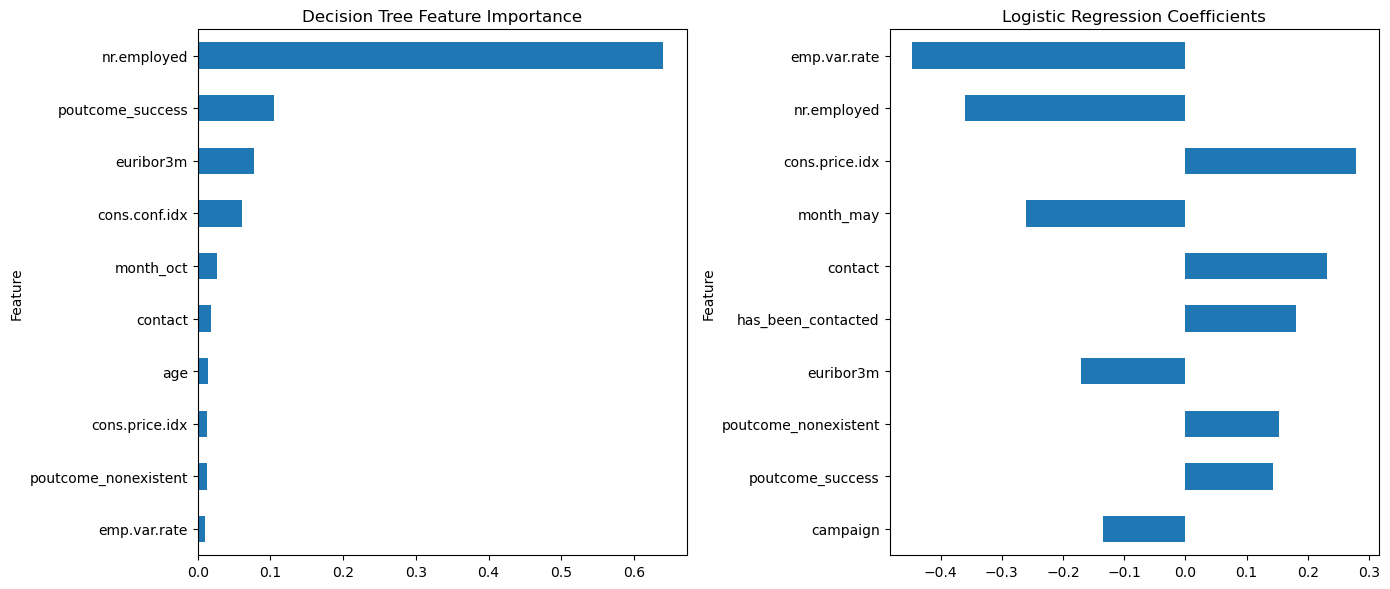

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Decision Tree
feat_importance_df.head(10).plot(
    kind='barh', x='Feature', y='Importance', ax=axes[0], legend=False)
axes[0].set_title('Decision Tree Feature Importance')
axes[0].invert_yaxis()

# Logistic Regression (absolute value = overall influence)
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df.nlargest(10, 'Abs').plot(
    kind='barh', x='Feature', y='Coefficient', ax=axes[1], legend=False)
axes[1].set_title('Logistic Regression Coefficients')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [46]:
# for SVC, it's too slow to do grid search, but we can try LinearSVC
from sklearn.svm import LinearSVC

linear_svc = LinearSVC(random_state=42, max_iter=5000)

start = time.time()
linear_svc.fit(X_train_scaled, y_train)
train_time = time.time() - start

start = time.time()
y_pred_svc = linear_svc.predict(X_test_scaled)
score_time = time.time() - start

print(f"Train time: {train_time:.4f}s")
print(f"Score time: {score_time:.4f}s")
print(f"Train accuracy {linear_svc.score(X_train_scaled, y_train):.4f}")
print(f"Test accuracy: {linear_svc.score(X_test_scaled, y_test):.4f}")

Train time: 0.1397s
Score time: 0.0003s
Train accuracy 0.9003
Test accuracy: 0.9030


In [47]:
param_grid = {'C': [0.01, 0.1, 1, 10]}
svc_grid = GridSearchCV(LinearSVC(random_state=42, max_iter=5000), param_grid, cv=5)
svc_grid.fit(X_train_scaled, y_train)
print('----- Linear SVC ------')
print_grid_search_results(svc_grid)

----- Linear SVC ------
Best params: {'C': 10}
Train accuracy: 0.9003
Test accuracy: 0.9030
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      6972
         yes       0.66      0.23      0.34       867

    accuracy                           0.90      7839
   macro avg       0.79      0.61      0.64      7839
weighted avg       0.88      0.90      0.88      7839

ROC-AUC: 0.6021


In [49]:
# try on LR and Decision Tree
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)
y_pred = lr_balanced.predict(X_test_scaled)
print("---- LR Balanced:")
print(f"Train acc: {lr_balanced.score(X_train_scaled, y_train)}")
print(f"Test acc: {lr_balanced.score(X_test_scaled, y_test)}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")

dt_balanced = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                      random_state=42, class_weight='balanced')
dt_balanced.fit(X_train_scaled, y_train)
y_pred = dt_balanced.predict(X_test_scaled)
print("\n---- DT Balanced:")
print(f"Train acc: {dt_balanced.score(X_train_scaled, y_train)}")
print(f"Test acc: {dt_balanced.score(X_test_scaled, y_test)}")
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")

---- LR Balanced:
Train acc: 0.8193735646848685
Test acc: 0.823574435514734
              precision    recall  f1-score   support

          no       0.95      0.85      0.90      6972
         yes       0.34      0.63      0.44       867

    accuracy                           0.82      7839
   macro avg       0.64      0.74      0.67      7839
weighted avg       0.88      0.82      0.85      7839

ROC-AUC: 0.7402

---- DT Balanced:
Train acc: 0.793697371778515
Test acc: 0.797805842581962
              precision    recall  f1-score   support

          no       0.95      0.81      0.88      6972
         yes       0.31      0.66      0.42       867

    accuracy                           0.80      7839
   macro avg       0.63      0.74      0.65      7839
weighted avg       0.88      0.80      0.83      7839

ROC-AUC: 0.7389


Accuracy is a misleading metric for this dataset. The default model's 89% accuracy is achieved by predicting "no" for everyone. The balanced model trades 7 points of accuracy for a huge improvement in recall on the minority class (63% for yes, where regular logistic regression was 23%) and a 13-point improvement in ROC-AUC — making it more useful for the actual business objective of identifying likely subscribers.

Both models agree that macroeconomic conditions dominate individual client characteristics in predicting subscription. nr.employed, euribor3m, and emp.var.rate consistently appear as top features across both the decision tree and logistic regression models. This suggests the bank's campaign timing relative to economic cycles may matter more than which specific clients are targeted. Additionally, the number of contacts was negatively correlated with subscriptions, so more contacts to the same person is not better.

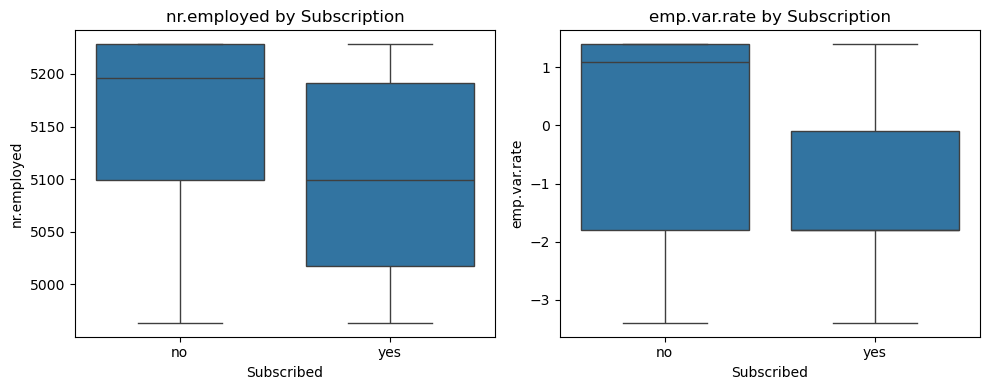

In [50]:
# plot economic conditions vs subscription
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['nr.employed', 'emp.var.rate']):
    sns.boxplot(x='y', y=col, data=df, ax=ax)
    ax.set_title(f'{col} by Subscription')
    ax.set_xlabel('Subscribed')

plt.tight_layout()
plt.show()


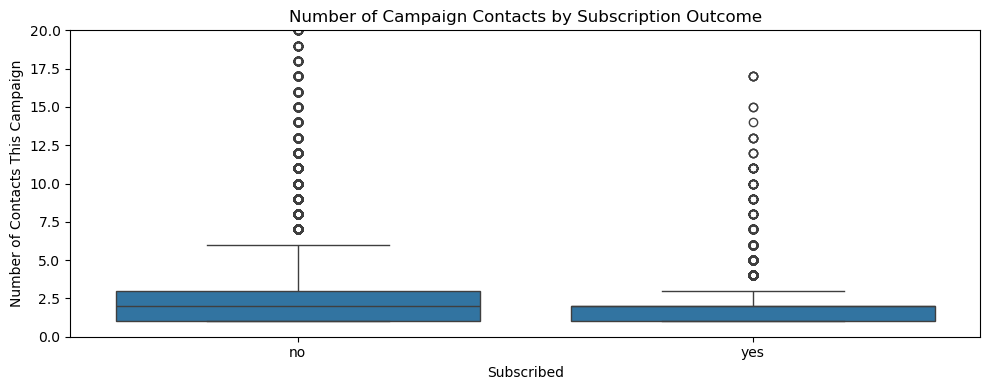

In [51]:
# number of contacts x subscription
plt.figure(figsize=(10, 4))
sns.boxplot(x='y', y='campaign', data=df)
plt.title('Number of Campaign Contacts by Subscription Outcome')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts This Campaign')
plt.ylim(0, 20)  # cap at 20 to remove outliers
plt.tight_layout()
plt.show()